In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("khizarjamshaid/pakistan-currency-dataset")

print("Path to dataset files:", path)

100%|██████████| 2.78G/2.78G [00:33<00:00, 88.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/khizarjamshaid/pakistan-currency-dataset/versions/2


In [ ]:
!pip install torch torchvision


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 112.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 93.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [ ]:

import numpy as np
import timm
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import torchvision
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import numpy as np
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy
from torch.utils.data import DataLoader

In [ ]:
print(os.listdir(path))
path = os.path.join(path,'Pakistan')


['Pakistan']


In [ ]:
print(os.listdir(path+'/Valid'))


['100Rsback', '500Rs', '5000Rsback', '10Rsback', '20Rs', 'others', '10Rs', '100Rs', '5000Rs', '1000Rs', '50Rsback', '50Rs', '1000Rsback', '20Rsback', '500Rsback']


In [ ]:
class CustomPreprocessing:
    def __init__(self, apply_equalization=False, apply_denoise=False, apply_edges=False):
        self.apply_equalization = apply_equalization
        self.apply_denoise = apply_denoise
        self.apply_edges = apply_edges

    def __call__(self, img: Image.Image):
        # Convert to OpenCV format
        img_np = np.array(img)

        # Apply histogram equalization (grayscale only)
        if self.apply_equalization:
            if len(img_np.shape) == 3 and img_np.shape[2] == 3:
                img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
            img_np = cv2.equalizeHist(img_np)

        # Denoising
        if self.apply_denoise:
            img_np = cv2.medianBlur(img_np, 3)

        # Edge detection (Canny)
        if self.apply_edges:
            img_np = cv2.Canny(img_np, 100, 200)

        # Convert back to 3-channel image if needed
        if len(img_np.shape) == 2:
            img_np = cv2.cvtColor(img_np, cv2.COLOR_GRAY2RGB)

        # Convert back to PIL for further torchvision transforms
        return Image.fromarray(img_np)


In [ ]:
transform = transforms.Compose([
    CustomPreprocessing(
        apply_equalization=False,
        apply_denoise=True,
        apply_edges=False  # set to True if needed
    ),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)  # For RGB images
])

In [ ]:
train_dataset = datasets.ImageFolder(root=path+'/Training', transform=transform)
test_dataset = datasets.ImageFolder(root=path+'/Valid', transform=transform)

In [ ]:
train_dataLoader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataLoader = DataLoader(test_dataset, batch_size=3216, shuffle=False)

In [ ]:
print(len(train_dataset.classes))

15


In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Load pre-trained EfficientNet model
model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=len(train_dataset.classes))
model = model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 15  # Adjust as needed

for epoch in range(num_epochs):
    for inputs, labels in train_dataLoader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

print('Finished Training')


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Streaming output truncated to the last 5000 lines.
Epoch [2/15], Loss: 0.0167
Epoch [2/15], Loss: 0.1305
Epoch [2/15], Loss: 0.5608
Epoch [2/15], Loss: 0.0573
Epoch [2/15], Loss: 0.5408
Epoch [2/15], Loss: 0.1002
Epoch [2/15], Loss: 0.0128
Epoch [2/15], Loss: 0.2733
Epoch [2/15], Loss: 0.0167
Epoch [2/15], Loss: 0.0142
Epoch [2/15], Loss: 0.0376
Epoch [2/15], Loss: 0.3368
Epoch [2/15], Loss: 0.0134
Epoch [2/15], Loss: 0.7647
Epoch [2/15], Loss: 0.1066
Epoch [2/15], Loss: 0.2343
Epoch [2/15], Loss: 0.0076
Epoch [2/15], Loss: 0.0012
Epoch [2/15], Loss: 0.0008
Epoch [2/15], Loss: 0.0254
Epoch [2/15], Loss: 0.2615
Epoch [2/15], Loss: 0.0146
Epoch [2/15], Loss: 0.2833
Epoch [2/15], Loss: 0.0454
Epoch [2/15], Loss: 0.0002
Epoch [2/15], Loss: 0.0079
Epoch [2/15], Loss: 0.0135
Epoch [2/15], Loss: 0.1592
Epoch [2/15], Loss: 0.0888
Epoch [2/15], Loss: 0.1577
Epoch [2/15], Loss: 0.2460
Epoch [2/15], Loss: 0.0986
Epoch [2/15], Loss: 0.3108
Epoch [2/15], Loss: 0.5707
Epoch [2/15], Loss: 0.0028
Epoc

In [ ]:
# 5. Evaluation
correct = 0
total = 0
model.eval()  # Set to evaluation mode
with torch.no_grad():
    for images, labels in test_dataLoader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy of the model on the test images: {accuracy:.2f}%")


Accuracy of the model on the test images: 97.05%


In [ ]:
torch.save(model.state_dict(), 'currency_classifier_model.pth')
print("Model saved as currency_classifier_model.pth")


Model saved as currency_classifier_model.pth


In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") # Define device here
model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=len(train_dataset.classes)) # Load without pretrained weights
# Explicitly load to CPU if CUDA is not available
model.load_state_dict(torch.load('currency_classifier_model(1).pth', map_location=torch.device('cpu')))
model = model.to(device) # Now you can safely move it to the correct device
model.eval() # Set the model to evaluation mode

EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2

In [ ]:
sum_list = []

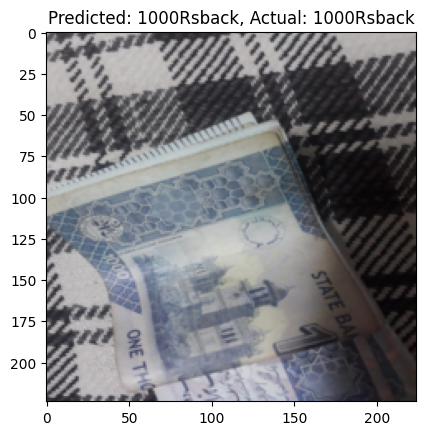

[10, 1000, 50, 500, 50, 1000, 5000, 1000]


In [ ]:
import random
import matplotlib.pyplot as plt
import re


# Assuming 'test_dataset' and 'model' are defined as in the provided code

# Select a random image from the test dataset
random_index = random.randint(0, len(test_dataset) - 1)
image, label = test_dataset[random_index]

# Make a prediction
model.eval()  # Ensure the model is in evaluation mode
with torch.no_grad():
    image = image.unsqueeze(0).to(device)  # Add batch dimension and move to device
    output = model(image)
    _, predicted = torch.max(output, 1)

# Get the class name from the predicted label
class_names = test_dataset.classes
predicted_class = class_names[predicted.item()]
actual_class = class_names[label]

# Extract integer part from predicted_class and append to sum_list
try:
    integer_part = re.search(r'\d+', predicted_class).group()
    integer_num = int(integer_part)
    sum_list.append(integer_num)
except (ValueError, AttributeError):
    print(f"Could not extract integer from: {predicted_class}")

# Display the image and prediction
image_np = image.squeeze(0).cpu().numpy()
image_np = image_np * 0.5 + 0.5  # Reverse mean and std normalization
image_np = np.clip(image_np, 0, 1)
image_np = np.transpose(image_np, (1, 2, 0))

plt.imshow(image_np)
plt.title(f"Predicted: {predicted_class}, Actual: {actual_class}")
plt.show()

print(sum_list)  # Print the list of extracted integers

In [ ]:
sum_of_numbers = __builtins__.sum(sum_list)
print(f"The sum of numbers in sum_list is: {sum_of_numbers}")

The sum of numbers in sum_list is: 8610
